In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs, extract_history, add_wall_times,
    plot_all_diagnostics, get_optimizer_colors, ALL_OPTIMIZERS,
    print_best_hyperparameters,
    DIAG_KEYS_METRIC_SCALE, DIAG_KEYS_LEARNABLE,
    DIAG_KEYS_CURVATURE, DIAG_KEYS_TRAINING, DIAG_KEYS_OFFDIAG,
)

from saddle_plots import (
    set_publication_style,
    FUNCTION_TITLES, HESSIAN_DIAG,
    KEY_PARAM_X, KEY_PARAM_Y, KEY_S0, KEY_S1,
    KEY_H0, KEY_H1, KEY_CS0, KEY_CS1,
    plot_hessian_estimates, plot_saddle_summary_grid,
    plot_metric_anisotropy, plot_clip_comparison,
)

set_publication_style()

# Configuration

In [2]:
# Backend: "wandb" or "local"
BACKEND = "local"

# WandB settings (ignored if BACKEND == "local")
PROJECT = "induced_metric"
ENTITY = "thomas_harvey"

# Results directory (for local backend)
RESULTS_DIR = os.path.join('..', '..', 'results')

# Test functions to analyse (saddle-specific; Rosenbrock etc. are in small_examples)
FUNCTIONS = ['saddle', 'weighted_saddle']

# Iterations to compare
ITERATIONS = {
    0: "With clip (default)",
    1: "No clip",
    2: "IMO-96 benchmark (1000 runs, bayes)",
}

# Auto-detect which optimizers have results for at least one function
if BACKEND == "local":
    _available = set()
    for func_name in FUNCTIONS:
        task_tag = func_name
        task_dir = os.path.join(RESULTS_DIR, task_tag)
        if os.path.isdir(task_dir):
            for name in os.listdir(task_dir):
                if os.path.isdir(os.path.join(task_dir, name)):
                    _available.add(name)
    OPTIMIZERS = sorted(_available)
else:
    OPTIMIZERS = ["adam", "sgd_learn_diag", "sgd_learn_diag_curv"]

colors = get_optimizer_colors(OPTIMIZERS)

print(f"Backend: {BACKEND}")
print(f"Functions: {FUNCTIONS}")
print(f"Optimizers: {OPTIMIZERS}")
print(f"Iterations: {ITERATIONS}")
print(f"Results dir: {os.path.abspath(RESULTS_DIR)}")

Backend: local
Functions: ['saddle', 'weighted_saddle']
Optimizers: ['adam', 'sgd', 'sgd_learn_diag', 'sgd_learn_diag_curv', 'sgd_newton_diag']
Iterations: {0: 'With clip (default)', 1: 'No clip', 2: 'IMO-96 benchmark (1000 runs, bayes)'}
Results dir: /Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/results


# Load Results

In [3]:
# Diagnostic keys — full tensor values for 2D problems
FULL_TENSOR_KEYS = [
    "diag/full/param/root/0", "diag/full/param/root/1",
    "diag/full/log_diag/root/0", "diag/full/log_diag/root/1",
    "diag/full/grad/root/0", "diag/full/grad/root/1",
    "diag/full/H_hat/0", "diag/full/H_hat/1",
    "diag/full/curv_sign/0", "diag/full/curv_sign/1",
    "diag/full/mom/root/0", "diag/full/mom/root/1",
    "diag/full/update/root/0", "diag/full/update/root/1",
]

HISTORY_KEYS = ["function_value", "runtime_seconds", "iteration"] + FULL_TENSOR_KEYS

# Load data for each iteration
# all_data[itr][func_name] = history_data dict
# all_runs[itr][func_name] = best_runs dict
all_data = {}
all_runs = {}

for itr, itr_label in ITERATIONS.items():
    print(f"\n{'='*60}")
    print(f"  ITERATION {itr}: {itr_label}")
    print(f"{'='*60}")

    itr_best = {}
    itr_hist = {}
    for func_name in FUNCTIONS:
        task_tag = func_name
        print(f"\n--- {func_name.upper()} ---")
        best_runs = load_best_runs(
            backend=BACKEND, optimizers=OPTIMIZERS, task_tag=task_tag,
            project=PROJECT, entity=ENTITY, results_dir=RESULTS_DIR,
            metric_key="sweep_metric", direction="minimize",
            sort_metric="sweep_metric", sort_order="+", iteration=itr,
        )
        itr_best[func_name] = best_runs
        if any(best_runs.values()):
            history_data = extract_history(BACKEND, best_runs, HISTORY_KEYS)
            add_wall_times(history_data, time_key="runtime_seconds")
            itr_hist[func_name] = history_data

    all_runs[itr] = itr_best
    all_data[itr] = itr_hist

# Default to iteration 2 for single-iteration plots
all_best_runs = all_runs[2]
all_history_data = all_data[2]

print("\nLoaded: itr0=", list(all_data.get(0,{}).keys()),
      "itr1=", list(all_data.get(1,{}).keys()),
      "itr2=", list(all_data.get(2,{}).keys()))


  ITERATION 0: With clip (default)

--- SADDLE ---
Finding best run for adam...
  adam: run_35
Finding best run for sgd...
  sgd: No runs found
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_13
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_19
Finding best run for sgd_newton_diag...
  sgd_newton_diag: No runs found
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...

--- WEIGHTED_SADDLE ---
Finding best run for adam...
  adam: run_35
Finding best run for sgd...
  sgd: No runs found
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_13
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_19
Finding best run for sgd_newton_diag...
  sgd_newton_diag: No runs found
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...

  ITERATION 1: No clip

--- SADDLE ---
Finding best run for adam...
  adam: run_35
Finding best run for sgd...
  sgd: No runs found
Finding best run f

  adam: run_665
Finding best run for sgd...
  sgd: run_1
Finding best run for sgd_learn_diag...
  sgd_learn_diag: No runs found
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_726
Finding best run for sgd_newton_diag...


  sgd_newton_diag: run_4
Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...

--- WEIGHTED_SADDLE ---
Finding best run for adam...


  adam: run_665
Finding best run for sgd...
  sgd: run_1
Finding best run for sgd_learn_diag...
  sgd_learn_diag: No runs found
Finding best run for sgd_learn_diag_curv...


  sgd_learn_diag_curv: run_467
Finding best run for sgd_newton_diag...


  sgd_newton_diag: run_4
Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...

Loaded: itr0= ['saddle', 'weighted_saddle'] itr1= ['saddle'] itr2= ['saddle', 'weighted_saddle']


# Summary Grid

Rows = test functions, columns = trajectory / $s_i$ evolution / loss curve.
All optimizers overlaid per cell.

/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/.conda/lib/python3.11/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


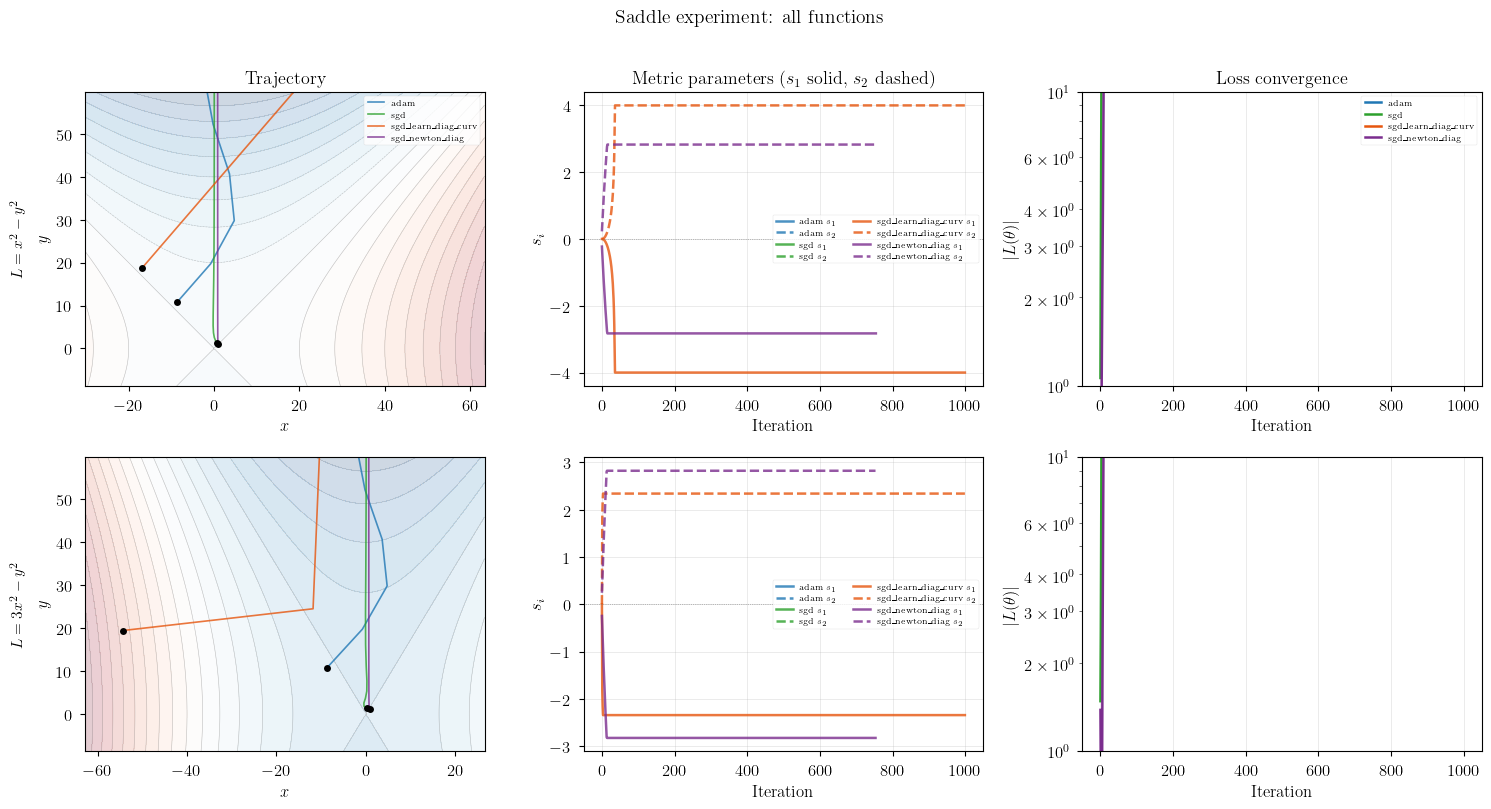

In [4]:
available_funcs = [f for f in FUNCTIONS if f in all_history_data]
plot_saddle_summary_grid(all_history_data, available_funcs,
                         optimizers=OPTIMIZERS, colors=colors)
plt.show()

# Secant Hessian Estimates (Curvature-Aware Only)

Left panel: secant $\hat{H}_{ii}$ vs iteration with true Hessian as dashed lines.
Right panel: $\tanh(\hat{H}_{ii} / \tau)$ (the curvature sign used in the update rule).

Shows noise level of secant estimator and how quickly the sign correction saturates.

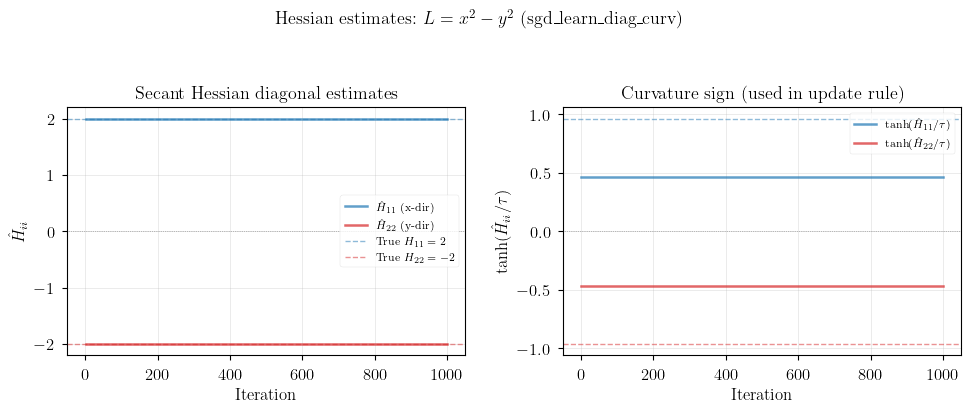

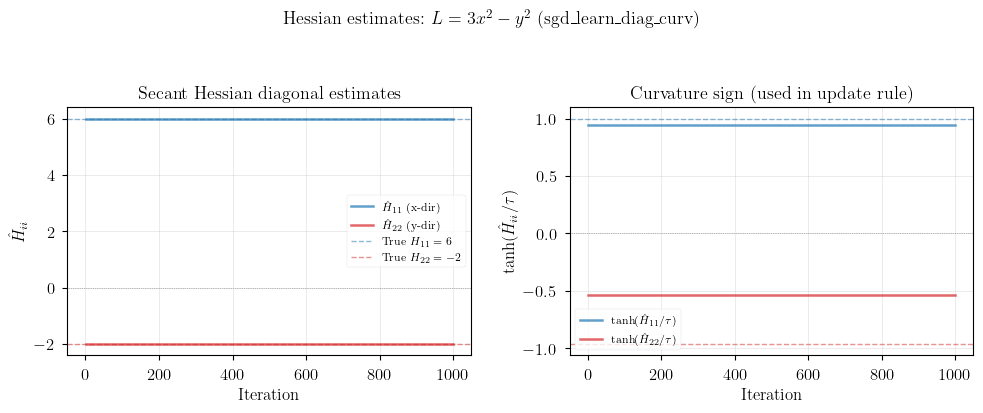

In [5]:
for func_name in available_funcs:
    plot_hessian_estimates(func_name, all_history_data[func_name],
                          hessian_diag=HESSIAN_DIAG)
    plt.show()

# Metric Anisotropy

Core claim: the curvature correction drives metric anisotropy ($|s_1 - s_2|$)
while the base learnable rule keeps $s_1 \approx s_2$ (symmetric gradients).

On the canonical saddle with mean-centering, $s_1 = -s_2$, so $|s_1 - s_2| = 2|s_1|$.

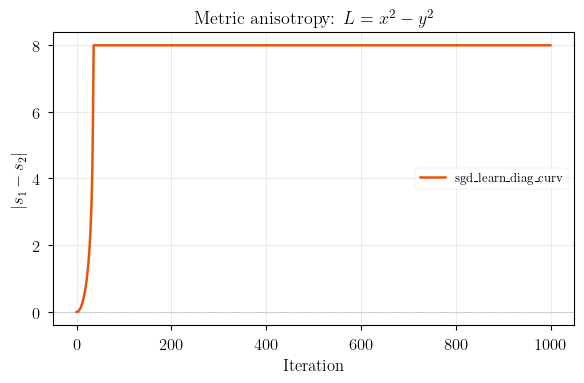

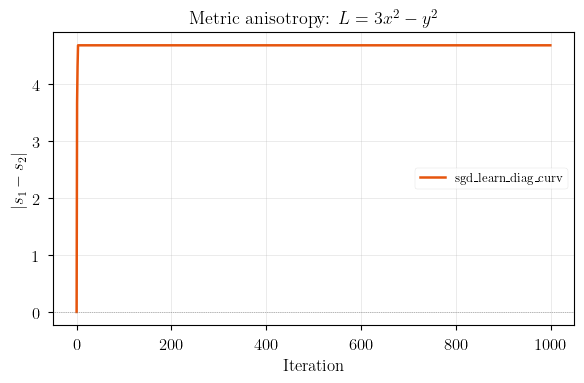

In [6]:
for func_name in available_funcs:
    plot_metric_anisotropy(func_name, all_history_data[func_name], colors=colors)
    plt.show()

# Clip Comparison: With clip (iter 0) vs No clip (iter 1)

Side-by-side comparison of all diagnostics. The clip is structurally necessary:
`exp(s) * g^2` drives s exponentially while regularization is only linear,
so s diverges without a hard bound. The question is what clip value to use.

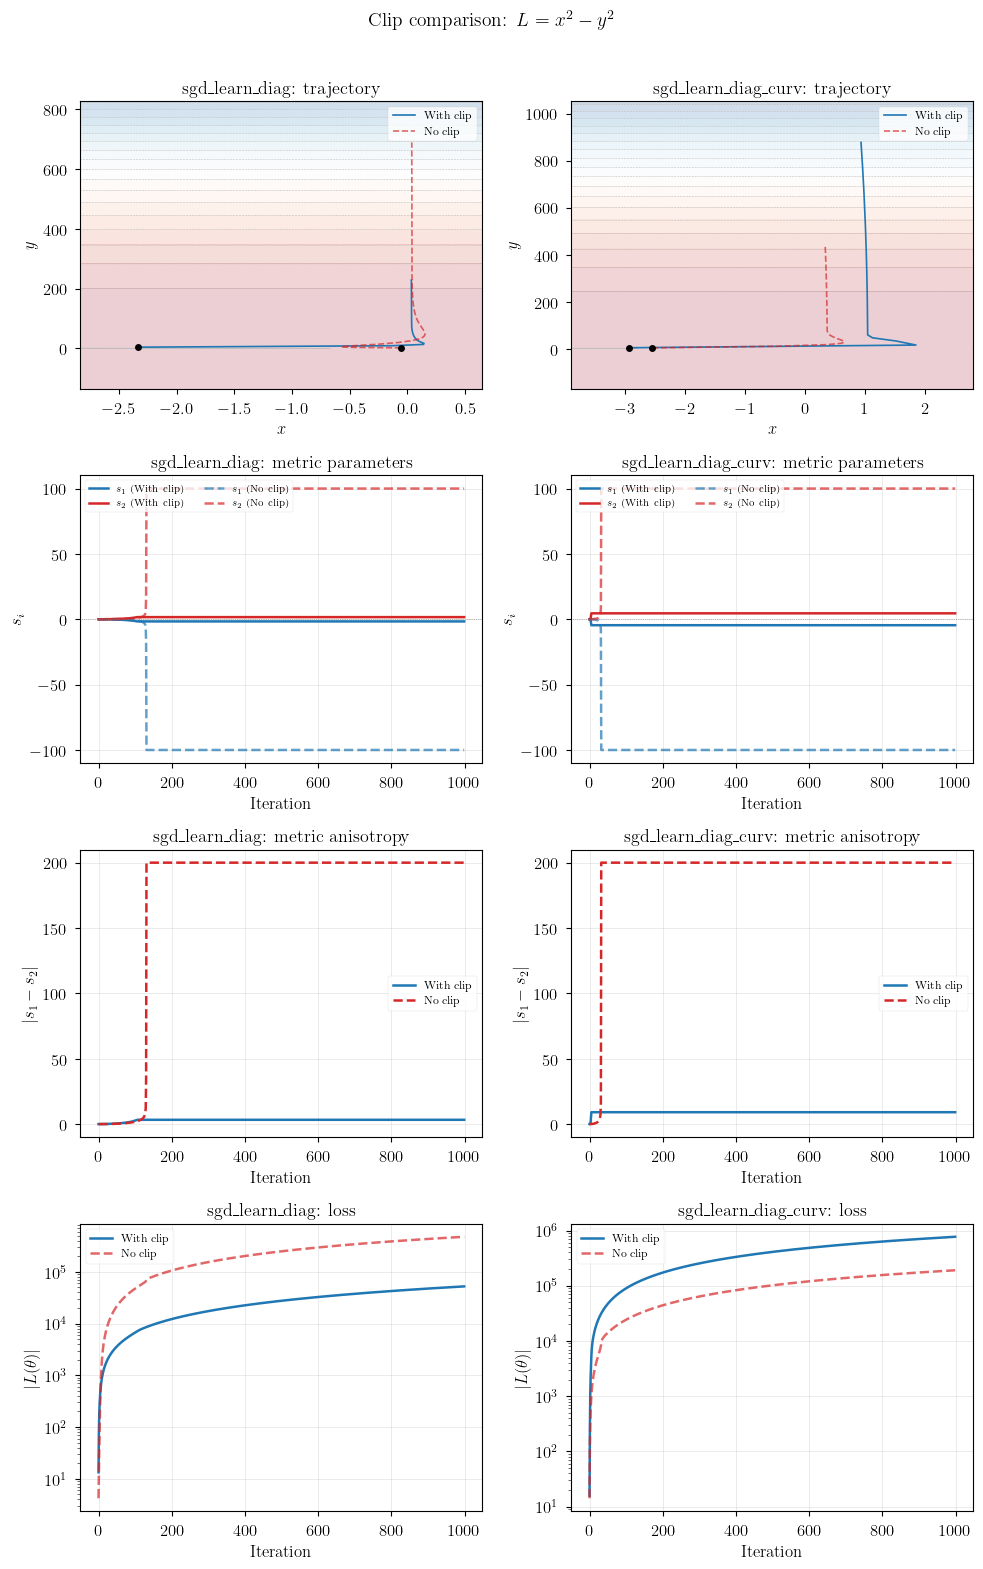

In [7]:
for func_name in FUNCTIONS:
    if func_name in all_data.get(0, {}) and func_name in all_data.get(1, {}):
        plot_clip_comparison(func_name, all_data=all_data,
                             function_titles=FUNCTION_TITLES)
        plt.show()

# Rosenbrock Comparison: Does $s_i$ stabilize near a minimum?

On the saddle, $s_i$ diverges without clip because $g \neq 0$ everywhere.
On Rosenbrock, $g \to 0$ near the minimum — does this naturally stabilize $s$?
If so, the clip is a safety net for saddle-like transients, not a fundamental limitation.

Finding best run for adam...
  adam: run_322
Finding best run for sgd_learn_diag...


  sgd_learn_diag: run_22
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_427
Processing adam...
Processing sgd_learn_diag...
Processing sgd_learn_diag_curv...


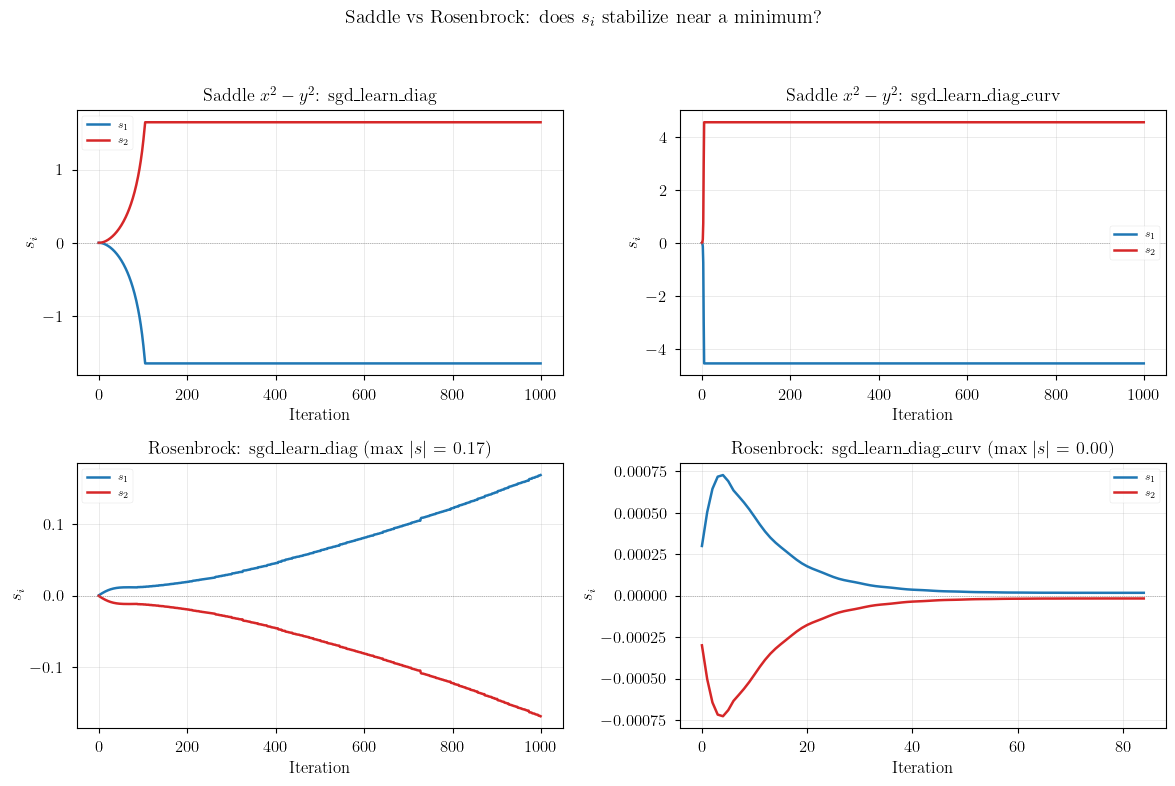

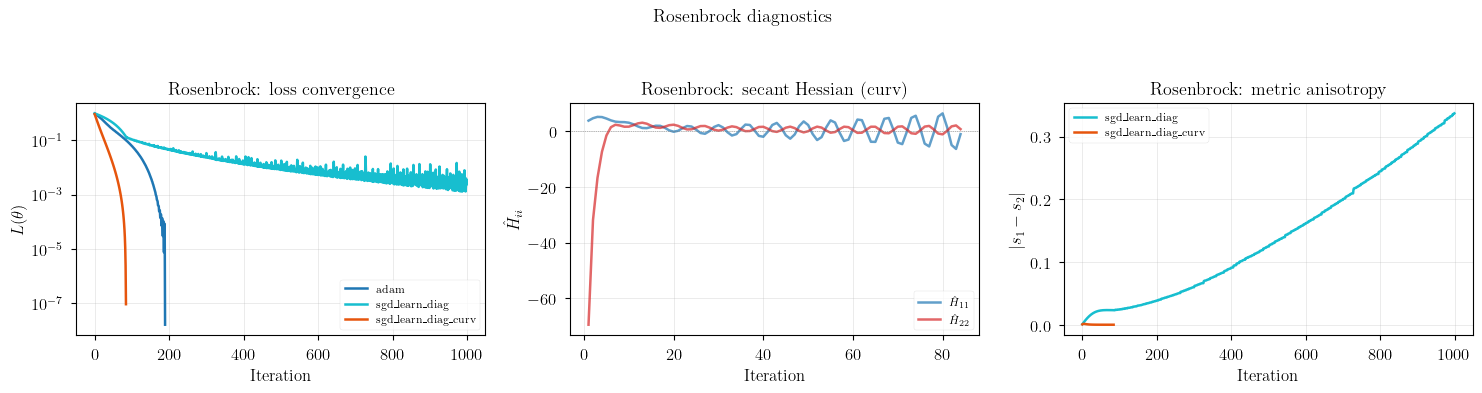


  ROSENBROCK s_i SUMMARY

  sgd_learn_diag:
    s_1 final=0.1685, s_2 final=-0.1685
    max |s| = 0.17
    |s1-s2| final = 0.3371
    Loss final = 0.002411
    Saturated at clip? NO

  sgd_learn_diag_curv:
    s_1 final=0.0000, s_2 final=-0.0000
    max |s| = 0.00
    |s1-s2| final = 0.0000
    Loss final = 0.000000
    Saturated at clip? NO


In [8]:
# Load Rosenbrock diagnostics (itr 4 = with diagnostics)
ROSEN_OPTS = ["adam", "sgd_learn_diag", "sgd_learn_diag_curv"]
rosen_best = load_best_runs(
    backend=BACKEND, optimizers=ROSEN_OPTS,
    task_tag="small_examples_rosenbrock",
    project=PROJECT, entity=ENTITY, results_dir=RESULTS_DIR,
    metric_key="sweep_metric", direction="minimize",
    sort_metric="sweep_metric", sort_order="+", iteration=4,
)
rosen_hist = extract_history(BACKEND, rosen_best, HISTORY_KEYS)

# Side-by-side: saddle vs Rosenbrock s_i evolution
learnable = ["sgd_learn_diag", "sgd_learn_diag_curv"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, opt_name in enumerate(learnable):
    opt_label = opt_name.replace("_", r"\_")

    # Top row: saddle s_i
    ax = axes[0, col]
    sd = all_data.get(0, {}).get("saddle", {}).get(opt_name, {})
    s0, s1 = sd.get(KEY_S0), sd.get(KEY_S1)
    if s0 is not None:
        steps = np.arange(len(s0))
        ax.plot(steps, s0, color="#1f77b4", label=r"$s_1$")
        ax.plot(steps, s1, color="#d62728", label=r"$s_2$")
    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$s_i$")
    ax.set_title(f"Saddle $x^2 - y^2$: {opt_label}")
    ax.legend(fontsize=8)
    ax.grid(True)

    # Bottom row: Rosenbrock s_i
    ax = axes[1, col]
    rd = rosen_hist.get(opt_name, {})
    s0, s1 = rd.get(KEY_S0), rd.get(KEY_S1)
    if s0 is not None:
        steps = np.arange(len(s0))
        ax.plot(steps, s0, color="#1f77b4", label=r"$s_1$")
        ax.plot(steps, s1, color="#d62728", label=r"$s_2$")
        s_max = max(np.max(np.abs(s0)), np.max(np.abs(s1)))
        ax.set_title(f"Rosenbrock: {opt_label} (max $|s|$ = {s_max:.2f})")
    else:
        ax.set_title(f"Rosenbrock: {opt_label} (no data)")
    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$s_i$")
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle(r"Saddle vs Rosenbrock: does $s_i$ stabilize near a minimum?", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Also show Rosenbrock loss convergence and H_hat
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for opt_name in ROSEN_OPTS:
    rd = rosen_hist.get(opt_name, {})
    loss = rd.get("function_value")
    if loss is not None:
        steps = np.arange(len(loss))
        ax.plot(steps, loss, color=colors.get(opt_name, "#333"),
                label=opt_name.replace("_", r"\_"))
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$L(\theta)$")
ax.set_yscale("log")
ax.set_title("Rosenbrock: loss convergence")
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
rd = rosen_hist.get("sgd_learn_diag_curv", {})
h0, h1 = rd.get(KEY_H0), rd.get(KEY_H1)
if h0 is not None:
    steps = np.arange(len(h0))
    ax.plot(steps, h0, color="#1f77b4", alpha=0.7, label=r"$\hat{H}_{11}$")
    ax.plot(steps, h1, color="#d62728", alpha=0.7, label=r"$\hat{H}_{22}$")
    ax.axhline(0, color="0.5", linewidth=0.5, linestyle=":")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\hat{H}_{ii}$")
ax.set_title("Rosenbrock: secant Hessian (curv)")
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[2]
for opt_name in learnable:
    rd = rosen_hist.get(opt_name, {})
    s0, s1 = rd.get(KEY_S0), rd.get(KEY_S1)
    if s0 is not None:
        aniso = np.abs(s0 - s1)
        steps = np.arange(len(aniso))
        ax.plot(steps, aniso, color=colors.get(opt_name, "#333"),
                label=opt_name.replace("_", r"\_"))
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$|s_1 - s_2|$")
ax.set_title("Rosenbrock: metric anisotropy")
ax.legend(fontsize=8)
ax.grid(True)

fig.suptitle("Rosenbrock diagnostics", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Print summary
print("\n" + "="*60)
print("  ROSENBROCK s_i SUMMARY")
print("="*60)
for opt_name in learnable:
    rd = rosen_hist.get(opt_name, {})
    s0, s1 = rd.get(KEY_S0), rd.get(KEY_S1)
    loss = rd.get("function_value")
    if s0 is not None:
        s_max = max(np.max(np.abs(s0)), np.max(np.abs(s1)))
        saturated = len(s0) > 100 and abs(s0[-1] - s0[-100]) < 0.01 and s_max > 3.0
        print(f"\n  {opt_name}:")
        print(f"    s_1 final={s0[-1]:.4f}, s_2 final={s1[-1]:.4f}")
        print(f"    max |s| = {s_max:.2f}")
        print(f"    |s1-s2| final = {abs(s0[-1]-s1[-1]):.4f}")
        print(f"    Loss final = {loss[-1]:.6f}")
        print(f"    Saturated at clip? {'YES' if saturated else 'NO'}")

# Standard Diagnostics

Reuse the shared diagnostic plotting infrastructure from `analysis_utils`.
Requires `--diagnostics` flag during sweep runs.

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


  [skip] No data for requested keys in: $L = x^2 - y^2$: Off-Diagonal (Woodbury) Diagnostics


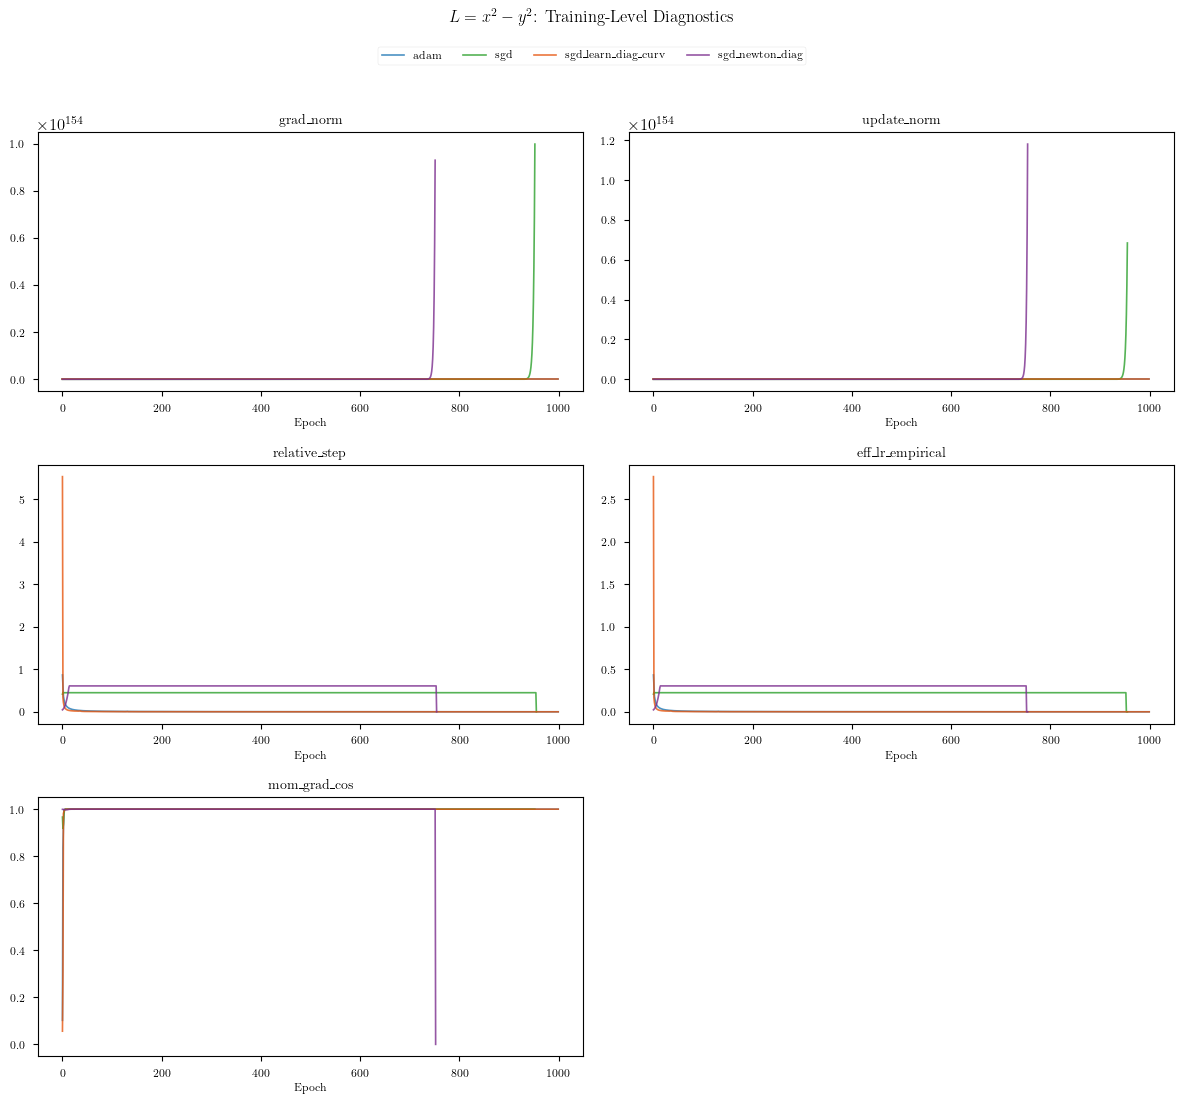

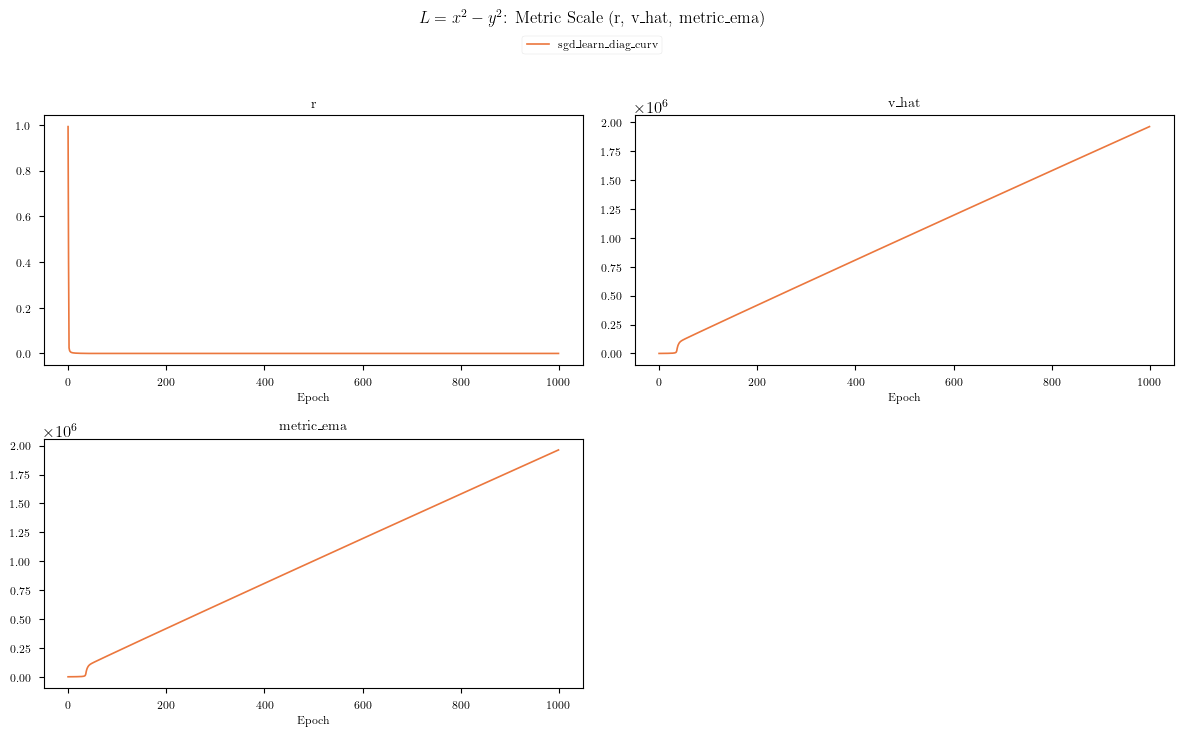

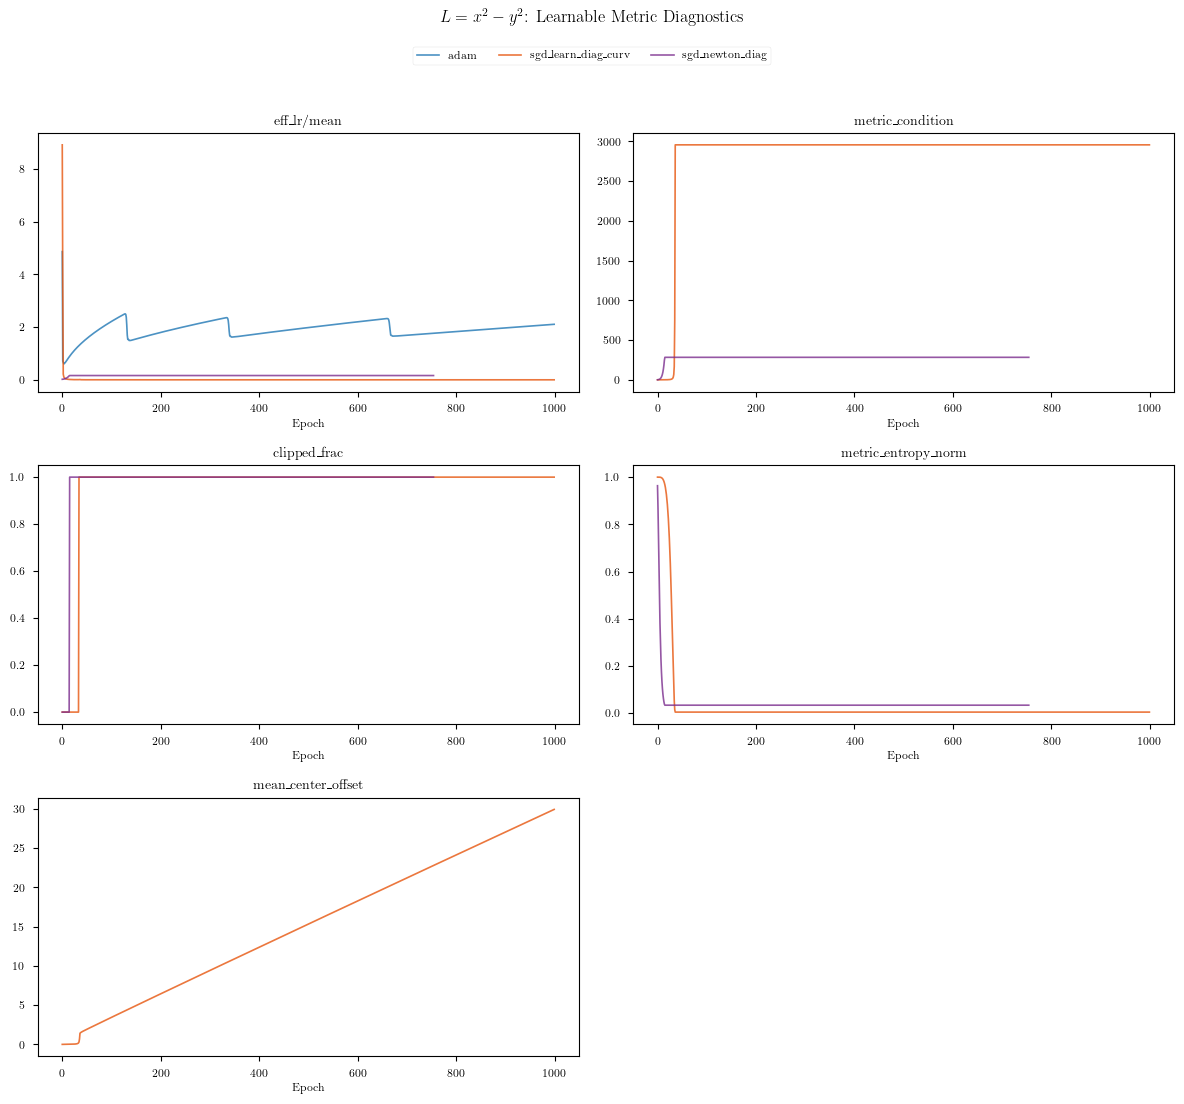

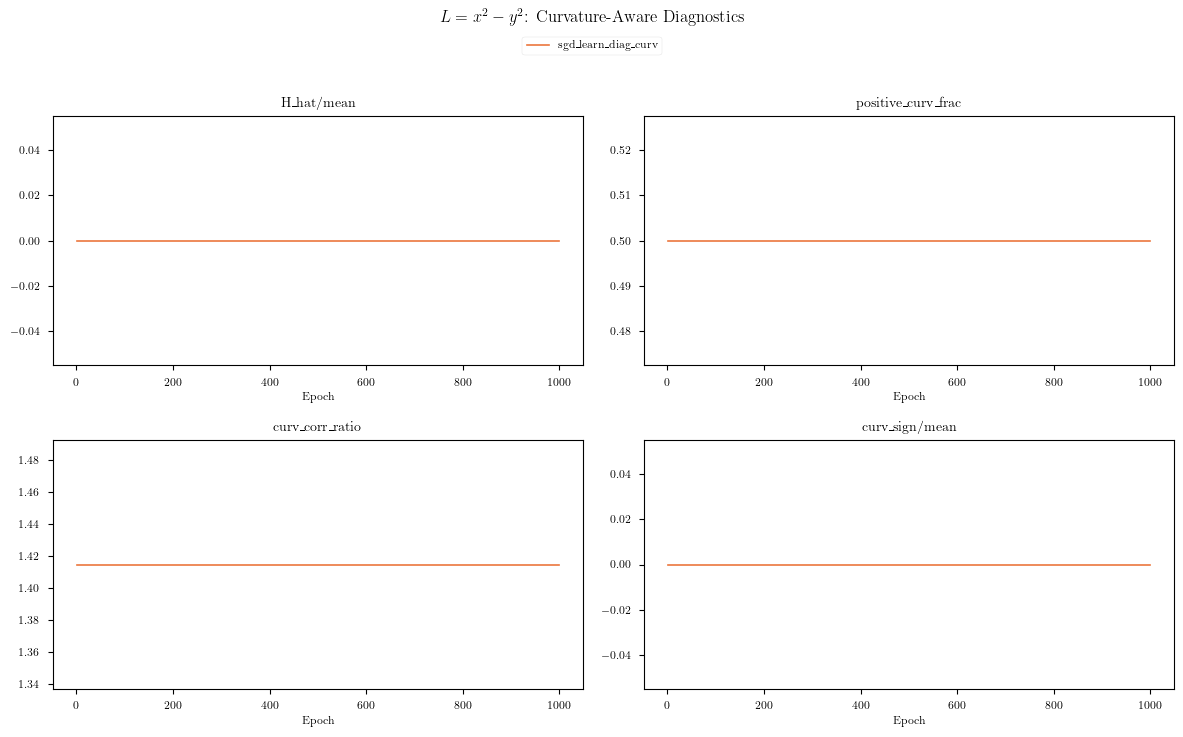

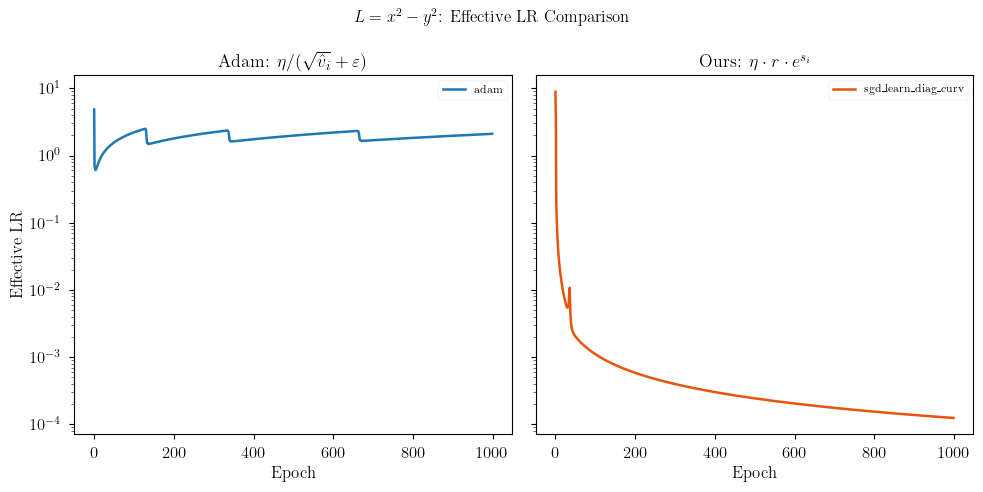

Processing adam...
Processing sgd...
Processing sgd_learn_diag_curv...
Processing sgd_newton_diag...


  [skip] No data for requested keys in: $L = 3x^2 - y^2$: Off-Diagonal (Woodbury) Diagnostics


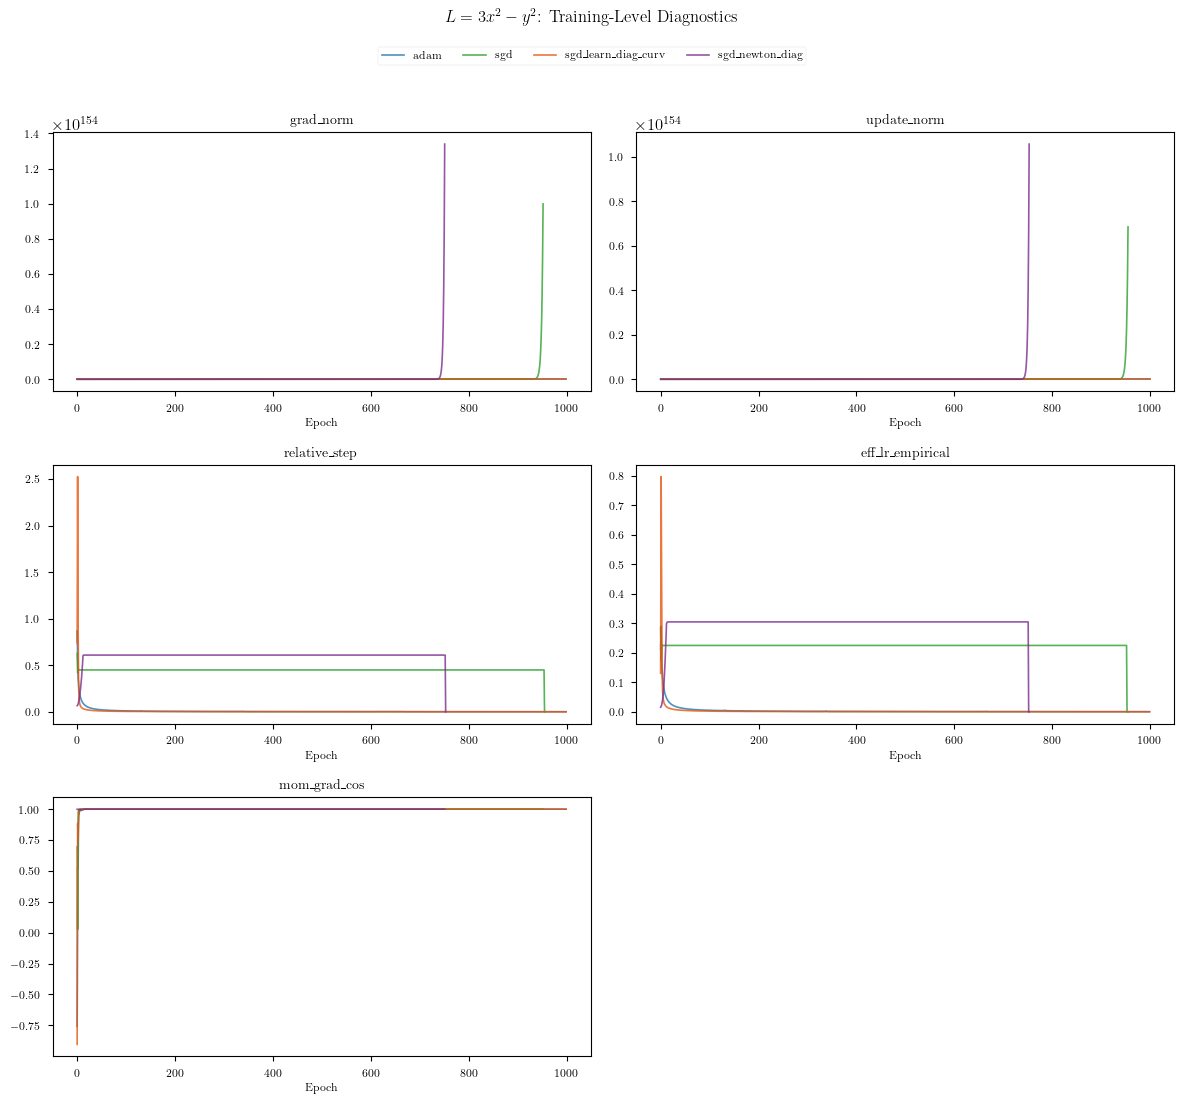

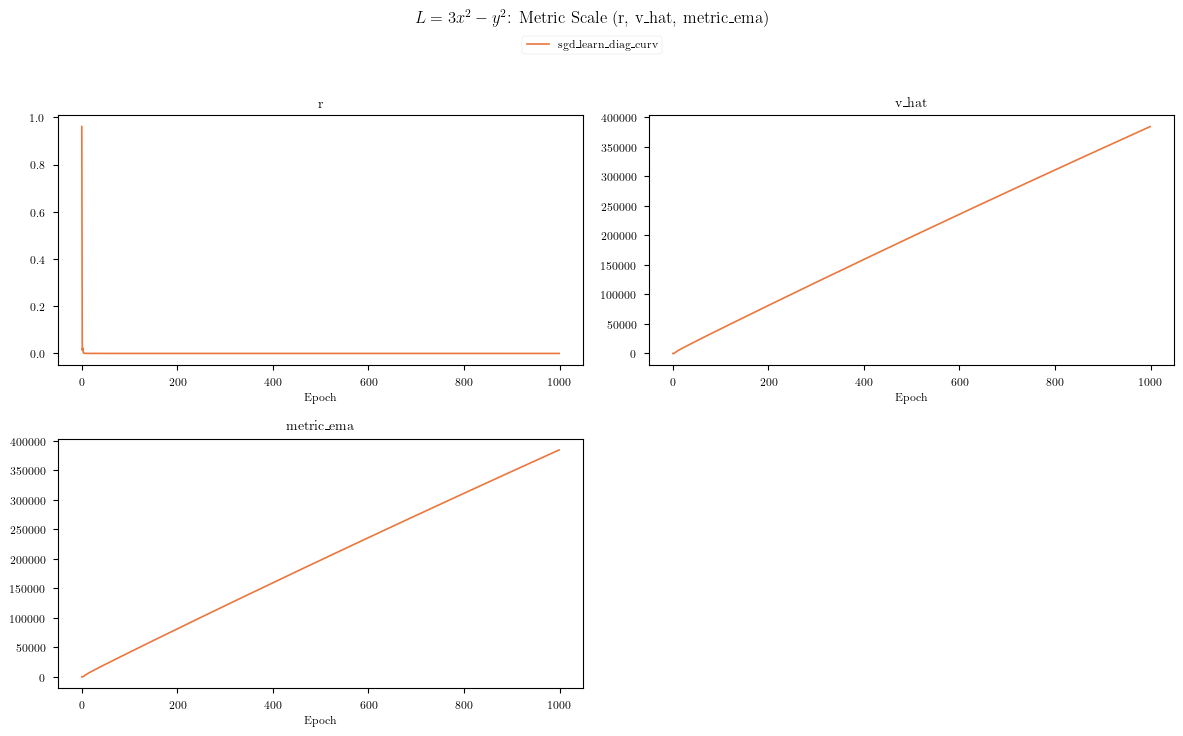

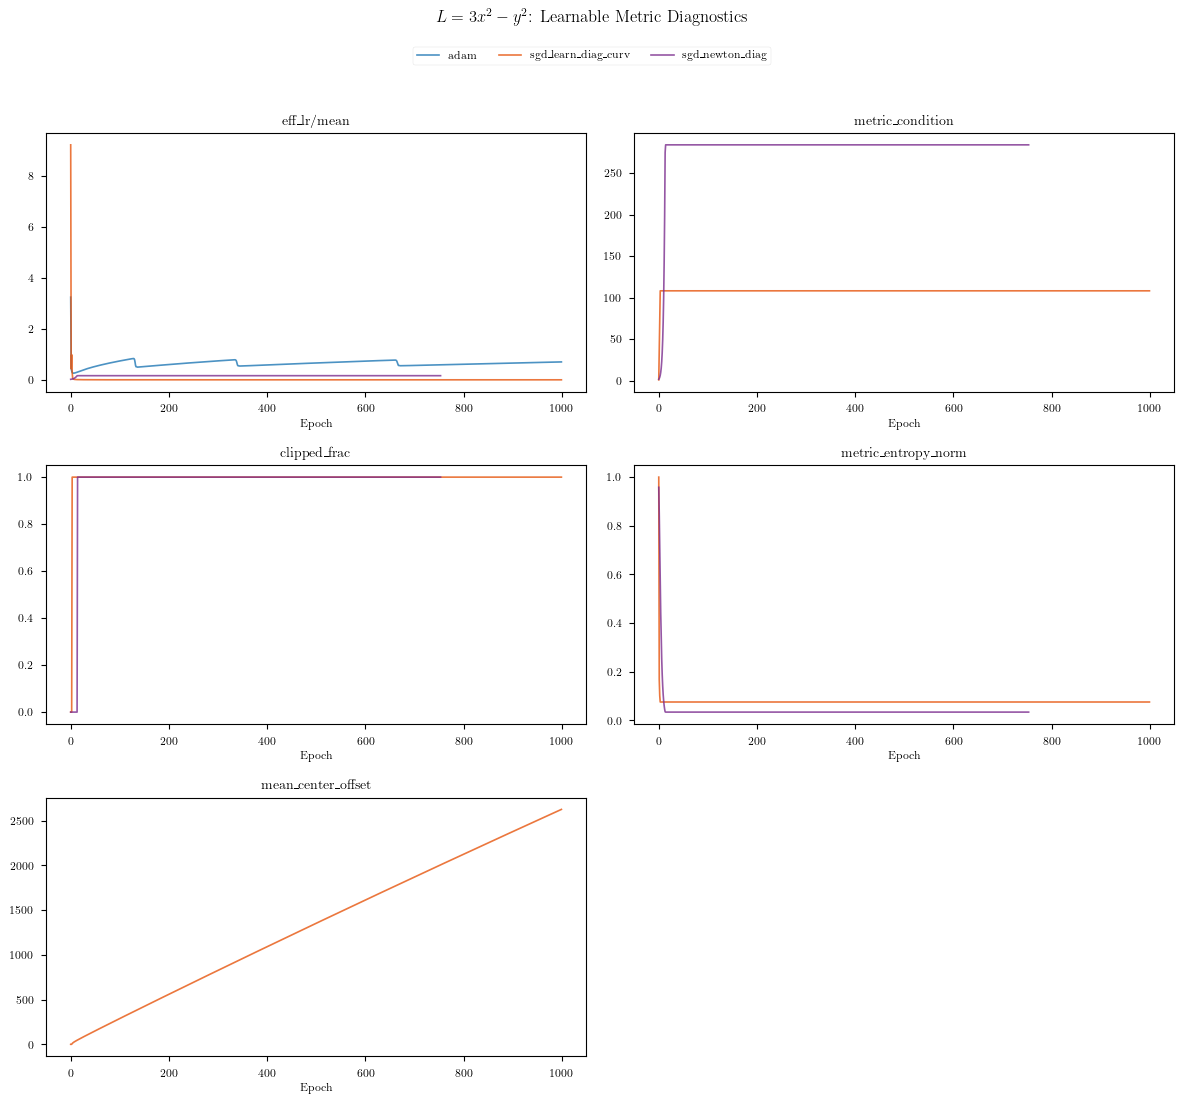

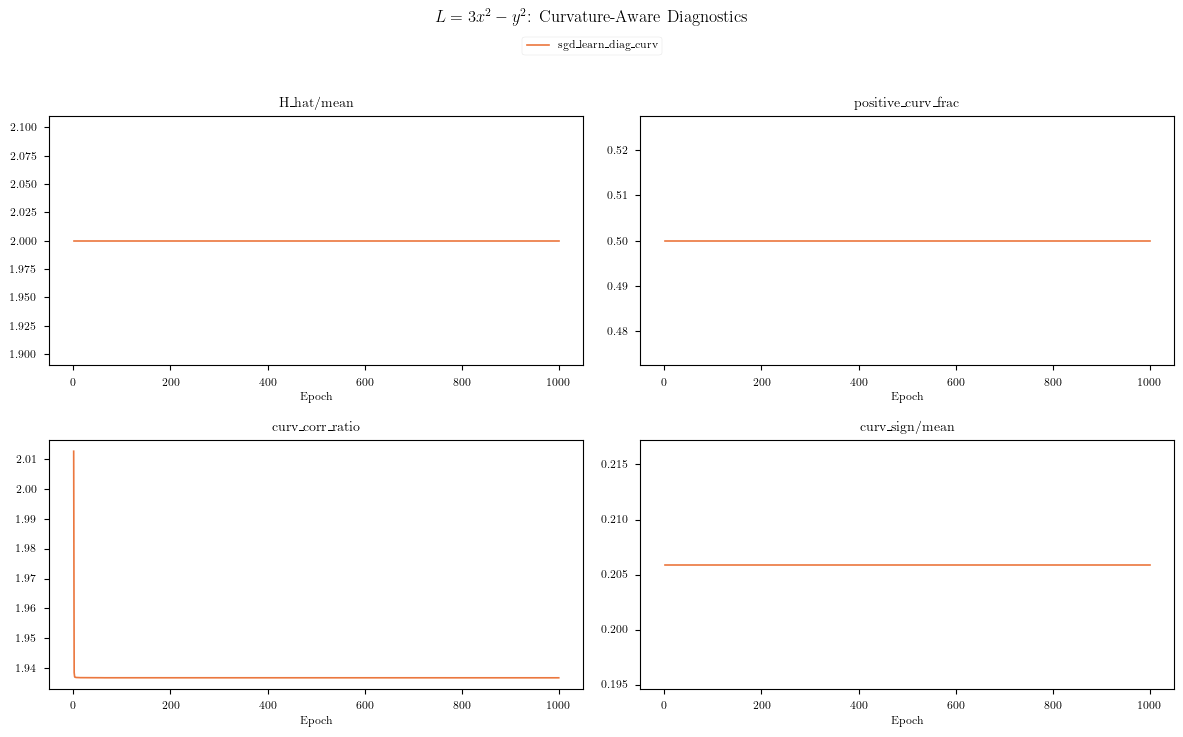

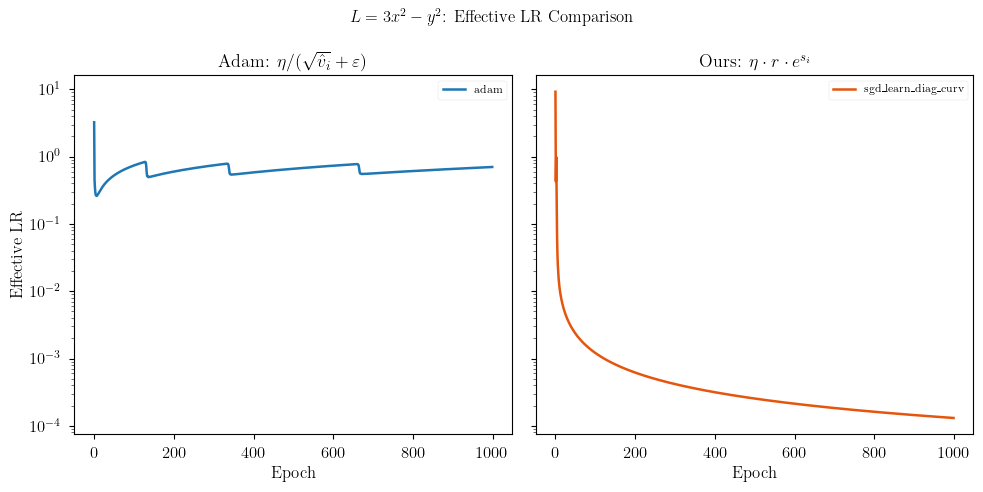

In [9]:
diag_keys = (
    DIAG_KEYS_METRIC_SCALE + DIAG_KEYS_LEARNABLE +
    DIAG_KEYS_CURVATURE + DIAG_KEYS_TRAINING
)

for func_name in available_funcs:
    best_runs = all_best_runs.get(func_name, {})
    if not best_runs:
        continue
    diag_data = extract_history(BACKEND, best_runs, diag_keys)
    title_fn = FUNCTION_TITLES.get(func_name, func_name)
    figs = plot_all_diagnostics(diag_data, title_prefix=title_fn, colors=colors)
    for fig, name in figs:
        plt.show()

# Best Hyperparameters

In [10]:
for func_name in available_funcs:
    best_runs = all_best_runs.get(func_name, {})
    if not best_runs:
        continue
    print(f"\n{'='*60}")
    print(f"  {func_name.upper()}: Best Hyperparameters")
    print(f"{'='*60}")
    print_best_hyperparameters(best_runs)


  SADDLE: Best Hyperparameters
Hyperparameters for Best Runs

ADAM:
  Run name: run_665
  Config:
    learning_rate: 9.719661516430026
    beta1: 0.6062072413412891
    beta2: 0.9994842063303524
    eps: 1.651627135405905e-08
    max_iterations: 1000
  sweep_metric: -262106097.294330
----------------------------------------

SGD:
  Run name: run_1
  Config:
    learning_rate: 0.1330324510152292
    momentum: 0.5926718993550663
    max_iterations: 1000
  sweep_metric: -inf
----------------------------------------

SGD_LEARN_DIAG_CURV:
  Run name: run_726
  Config:
    learning_rate: 8.978685944099984
    momentum: 0.2862684894103362
    xi: 0.0010052558622501897
    beta: 0.680672866015005
    weight_decay: 1.2863974007932669e-06
    metric_lr: 3.040489873007873e-05
    metric_reg: 2.2106261424595704e-05
    metric_clip: 2.4851892887585305
    curv_beta: 0.0030589562782060574
    curv_tau: 3.972024217293437
    metric_param: exp_adaptive_clip
    max_iterations: 1000
    max_condition_